In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import datasets, layers, models

In [ ]:
(x_train,y_train),(x_test,y_test)=datasets.cifar10.load_data()

In [ ]:
x_train.shape

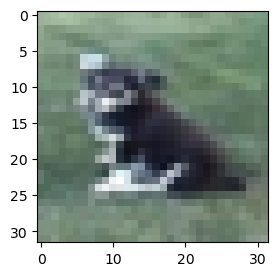

In [10]:
plt.figure(figsize=(17,3))
plt.imshow(x_train[70])

In [11]:
y_train=y_train.reshape(-1,)
y_train[:5]
y_train.shape

(50000,)

In [12]:
y_test=y_test.reshape(-1,)

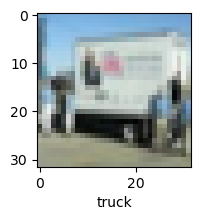

In [13]:
classes=['airoplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
def sample(x,y,index):
    plt.figure(figsize=(13,2))
    plt.imshow(x[index])
    plt.xlabel(classes[y[index]])
sample(x_train,y_train,76)

In [14]:
x_train=x_train/255
x_train.shape

(50000, 32, 32, 3)

In [15]:
x_test=x_test/225

In [16]:
mod=models.Sequential([layers.Flatten(input_shape=(32,32,3)),
                       layers.Dense(3000,activation='relu'),
                      layers.Dense(1000,activation='relu'),
                      layers.Dense(10,activation='sigmoid')])
mod.compile(optimizer='SGD',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
mod.fit(x_train,y_train,epochs=5)

C:\Users\yoges\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 44s 27ms/step - accuracy: 0.3034 - loss: 1.9336
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 44s 28ms/step - accuracy: 0.4183 - loss: 1.6468
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 44s 28ms/step - accuracy: 0.4494 - loss: 1.5591
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 43s 27ms/step - accuracy: 0.4762 - loss: 1.4866
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 43s 27ms/step - accuracy: 0.4958 - loss: 1.4318


In [17]:
mod.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4769 - loss: 1.4618


[1.4649451971054077, 0.48260000348091125]

In [34]:
cnn=models.Sequential([ layers.Conv2D(filters=32,kernel_size=(3,3),activation='relu',input_shape=(32,32,3)),
                       layers.MaxPooling2D((2,2)),
                       layers.Conv2D(filters=32,kernel_size=(3,3),activation='relu',input_shape=(32,32,3)),
                       layers.MaxPooling2D((2,2)),
                        layers.Flatten(),
                       layers.Dense(64,activation='relu'),
                      layers.Dense(10,activation='softmax')])

In [36]:
cnn.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [38]:
cnn.fit(x_train,y_train,epochs=10)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.3712 - loss: 1.7071
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.5753 - loss: 1.1995
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.6395 - loss: 1.0429
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.6617 - loss: 0.9716
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.6861 - loss: 0.9044
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.7010 - loss: 0.8537
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.7184 - loss: 0.8143
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.7284 - loss: 0.7759
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.7461 - loss: 0.7367
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.7548 - loss: 0.7094


In [40]:
cnn.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6910 - loss: 0.9438


[0.9553037285804749, 0.6876000165939331]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.1333333333333333].


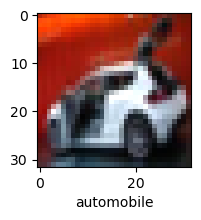

In [44]:
y_test=y_test.reshape(-1,)
sample(x_test,y_test,6)

In [56]:
y_pred=cnn.predict(x_test)
y_pred[:5]


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


array([[1.06582331e-04, 5.33593629e-06, 4.05139726e-04, 7.40240633e-01,
        5.89545642e-04, 2.51523435e-01, 3.00269714e-03, 7.19895397e-05,
        3.94340465e-03, 1.11205314e-04],
       [9.22637247e-03, 1.71143468e-02, 2.37064614e-06, 6.29718397e-06,
        3.25145884e-05, 5.80009612e-07, 4.05075120e-08, 6.90929141e-07,
        9.69251394e-01, 4.36538458e-03],
       [5.12118377e-02, 2.78818697e-01, 3.39658058e-04, 1.28084572e-03,
        7.67802179e-04, 1.31924040e-04, 1.25339895e-04, 1.03394594e-02,
        2.09112018e-01, 4.47872400e-01],
       [8.16259682e-01, 8.50299224e-02, 1.25006167e-03, 2.59490754e-03,
        4.72207816e-04, 7.70801562e-05, 3.91780515e-04, 1.35090551e-03,
        9.12086964e-02, 1.36475335e-03],
       [9.76409865e-07, 2.57938922e-07, 2.10336526e-03, 1.64948609e-02,
        4.40746307e-01, 3.34562035e-03, 5.37299335e-01, 7.50127720e-06,
        1.66993129e-06, 6.77002348e-08]], dtype=float32)

In [70]:
y_class=[np.argmax(element) for element in y_pred]
y_class[:7]

[3, 8, 9, 0, 6, 6, 3]

In [68]:
y_test[:7]

array([3, 8, 8, 0, 6, 6, 1], dtype=uint8)